# Image Classification on CIFAR-10 using CNN

This project builds a deep learning model to classify images from the CIFAR-10 dataset into 10 categories — airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck — using a Convolutional Neural Network (CNN) trained entirely from scratch.

The model incorporates advanced techniques including Batch Normalisation, Dropout, Data Augmentation, and Adaptive Learning Rate Scheduling to achieve strong generalisation performance.

In [1]:
# 1. Imports

import tensorflow as tf
from tensorflow.keras import datasets, layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# 2. Class labels

CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

In [3]:
# 3. Load CIFAR-10 directly from Keras

(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

y_train = y_train.reshape(-1)
y_test  = y_test.reshape(-1)

print(f"\nTraining samples : {X_train.shape}")
print(f"Test samples     : {X_test.shape}")


Training samples : (50000, 32, 32, 3)
Test samples     : (10000, 32, 32, 3)


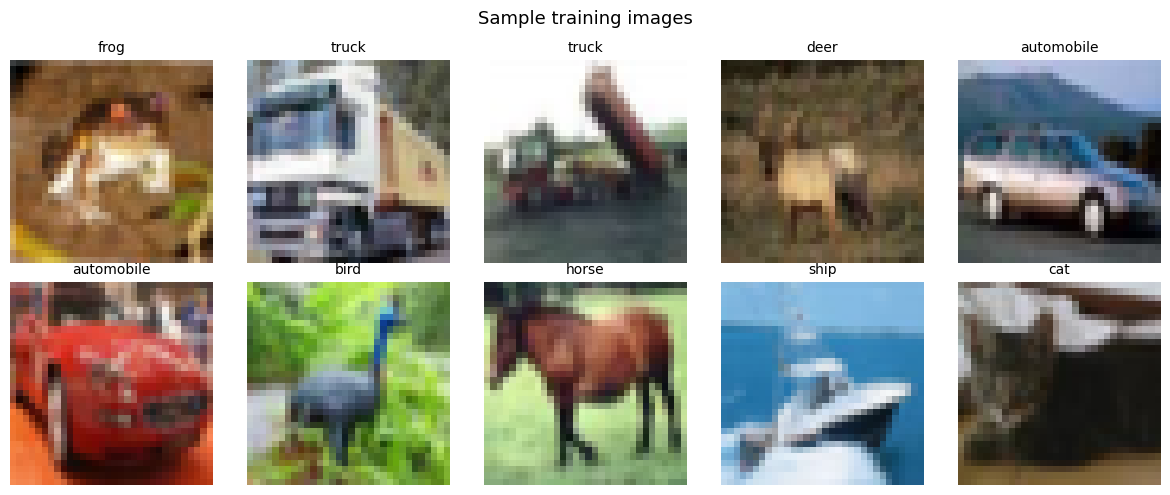

In [4]:
# 4. Preview some training images

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, i in zip(axes.flat, range(10)):
    ax.imshow(X_train[i])
    ax.set_title(CLASSES[y_train[i]], fontsize=10)
    ax.axis('off')
plt.suptitle('Sample training images', fontsize=13)
plt.tight_layout()
plt.show()

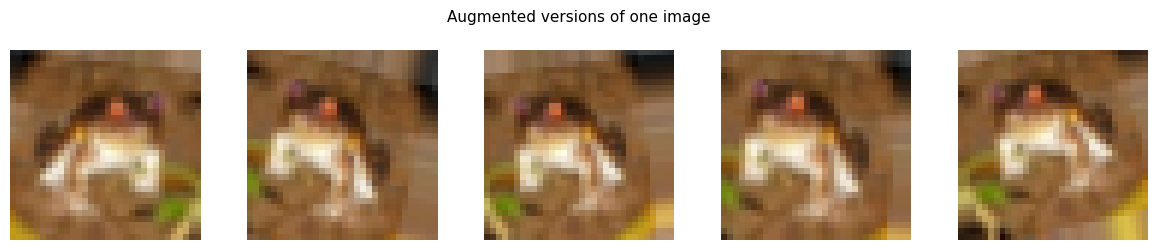

In [5]:
# 5. Data augmentation

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)
datagen.fit(X_train)

# Preview 5 augmented versions of one image
fig, axes = plt.subplots(1, 5, figsize=(12, 2.5))
sample = X_train[:1]
for ax, batch in zip(axes, datagen.flow(sample, batch_size=1)):
    ax.imshow(batch[0])
    ax.axis('off')
plt.suptitle('Augmented versions of one image', fontsize=11)
plt.tight_layout()
plt.show()

In [6]:
# 6. Build the advanced CNN model

def build_model():
    model = models.Sequential([

        # Block 1 — 32 filters
        layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                      input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 2 — 64 filters
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 3 — 128 filters
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.4),

        # Classifier head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [7]:
# 7. Compile — plain float LR so ReduceLROnPlateau works

# NOTE: Do NOT use CosineDecayRestarts here — it conflicts with
# ReduceLROnPlateau because schedule-based LRs are not settable.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
# 8. Callbacks

cb_early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

cb_checkpoint = callbacks.ModelCheckpoint(
    '/tmp/best_cifar10_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# This now works correctly with plain float LR
cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

In [9]:
# 9. Train

EPOCHS     = 100
BATCH_SIZE = 64

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_test, y_test),
    callbacks=[cb_early_stop, cb_checkpoint, cb_reduce_lr],
    verbose=1
)

Epoch 1/100
780/781 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3206 - loss: 2.1611
Epoch 1: val_accuracy improved from None to 0.48320, saving model to /tmp/best_cifar10_model.keras

Epoch 1: finished saving model to /tmp/best_cifar10_model.keras
781/781 ━━━━━━━━━━━━━━━━━━━━ 57s 56ms/step - accuracy: 0.4020 - loss: 1.7665 - val_accuracy: 0.4832 - val_loss: 1.5295 - learning_rate: 0.0010
Epoch 2/100
  1/781 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5469 - loss: 1.2909

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.48320 to 0.48490, saving model to /tmp/best_cifar10_model.keras

Epoch 2: finished saving model to /tmp/best_cifar10_model.keras
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5469 - loss: 1.2909 - val_accuracy: 0.4849 - val_loss: 1.5213 - learning_rate: 0.0010
Epoch 3/100
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5333 - loss: 1.3004
Epoch 3: val_accuracy improved from 0.48490 to 0.53610, saving model to /tmp/best_cifar10_model.keras

Epoch 3: finished saving model to /tmp/best_cifar10_model.keras
781/781 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.5586 - loss: 1.2348 - val_accuracy: 0.5361 - val_loss: 1.4512 - learning_rate: 0.0010
Epoch 4/100
  1/781 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.6406 - loss: 1.0681
Epoch 4: val_accuracy improved from 0.53610 to 0.55140, saving model to /tmp/best_cifar10_model.keras

Epoch 4: finished saving model to /tmp/best_cifar10_model.keras
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/s

In [10]:
# 10. Evaluate on test set

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal test accuracy : {test_acc * 100:.2f}%")
print(f"Final test loss     : {test_loss:.4f}")


Final test accuracy : 86.11%
Final test loss     : 0.4311


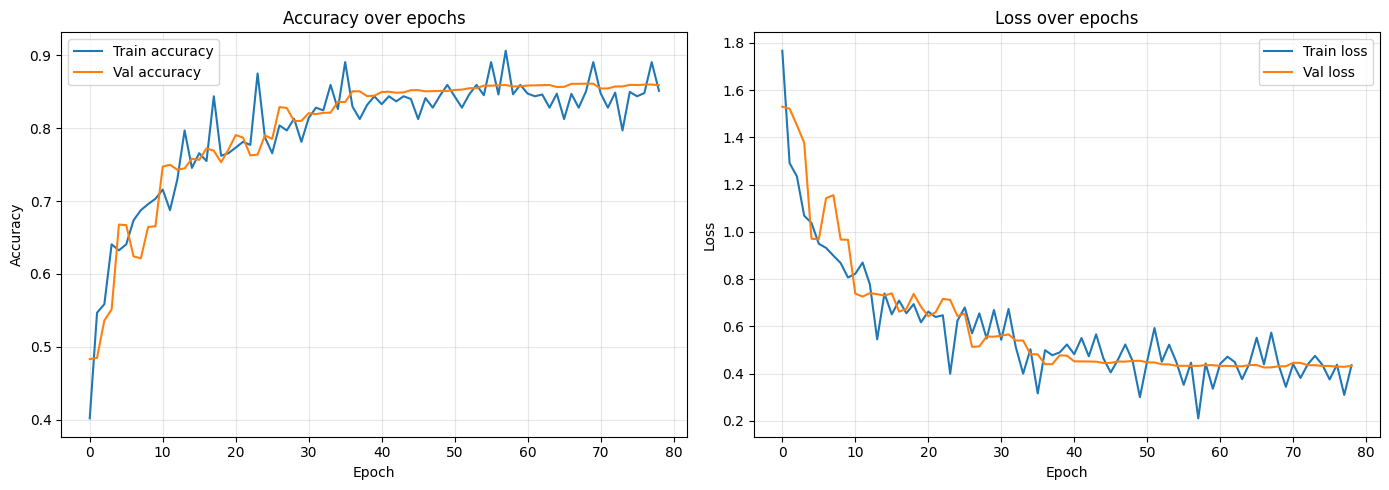

In [11]:
# 11. Plot training curves

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train accuracy')
ax1.plot(history.history['val_accuracy'], label='Val accuracy')
ax1.set_title('Accuracy over epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'],     label='Train loss')
ax2.plot(history.history['val_loss'], label='Val loss')
ax2.set_title('Loss over epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# 12. Predictions

y_pred        = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


In [13]:
# 13. Classification report (per-class metrics)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_labels, target_names=CLASSES))


Classification Report:
              precision    recall  f1-score   support

    airplane       0.89      0.88      0.89      1000
  automobile       0.93      0.94      0.94      1000
        bird       0.86      0.78      0.82      1000
         cat       0.83      0.65      0.73      1000
        deer       0.87      0.84      0.85      1000
         dog       0.86      0.76      0.81      1000
        frog       0.72      0.97      0.83      1000
       horse       0.90      0.91      0.90      1000
        ship       0.93      0.94      0.93      1000
       truck       0.85      0.95      0.90      1000

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000



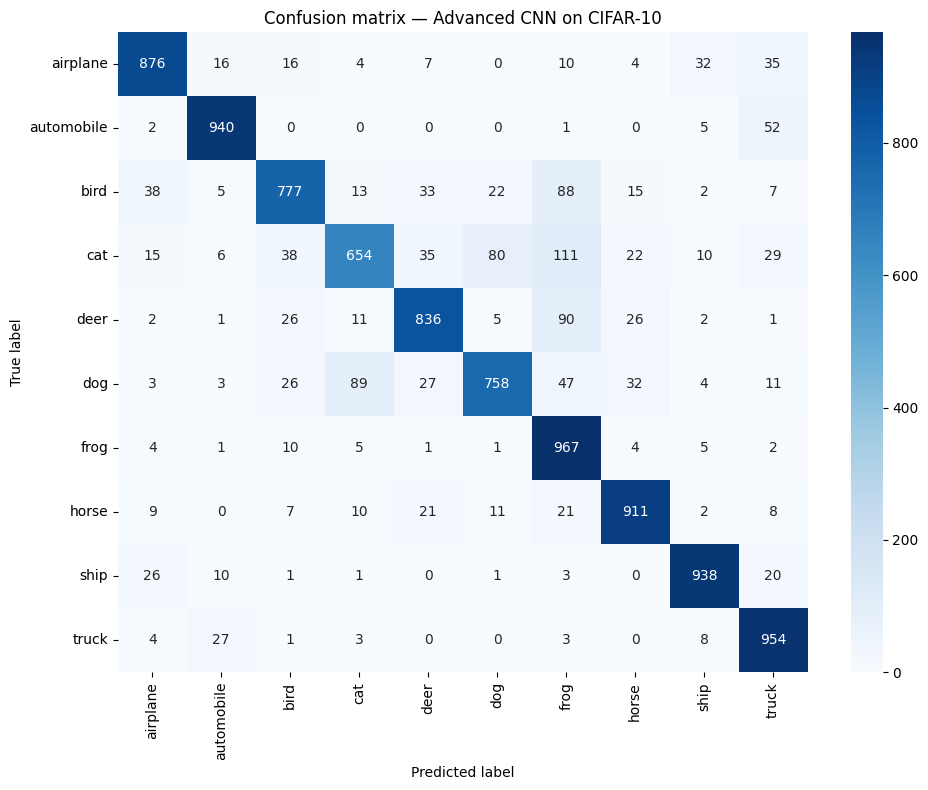

In [14]:
# 14. Confusion matrix heatmap

cm = confusion_matrix(y_test, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion matrix — Advanced CNN on CIFAR-10')
plt.tight_layout()
plt.show()

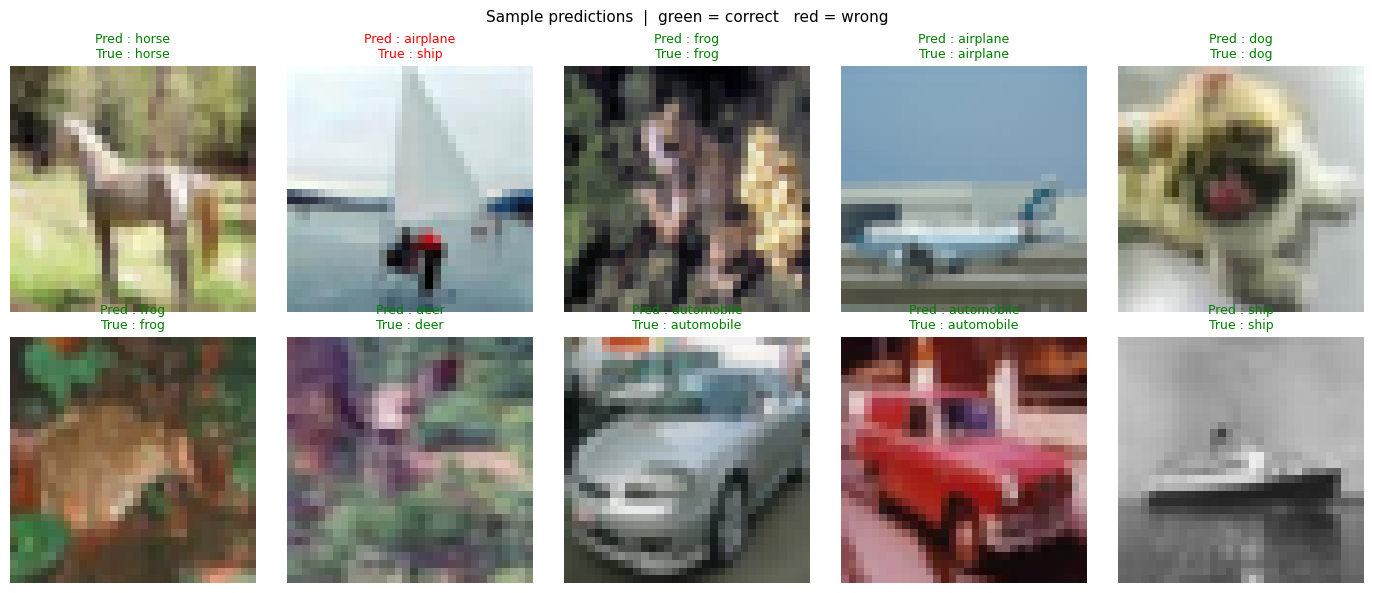

In [15]:
# 15. Visualise predictions (green = correct, red = wrong)

def show_predictions(n=10):
    idxs = np.random.choice(len(X_test), n, replace=False)
    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    for ax, i in zip(axes.flat, idxs):
        ax.imshow(X_test[i])
        pred  = CLASSES[y_pred_labels[i]]
        truth = CLASSES[y_test[i]]
        color = 'green' if pred == truth else 'red'
        ax.set_title(f"Pred : {pred}\nTrue : {truth}", color=color, fontsize=9)
        ax.axis('off')
    plt.suptitle('Sample predictions  |  green = correct   red = wrong', fontsize=11)
    plt.tight_layout()
    plt.show()

show_predictions()

In [16]:
# 16. Load best saved model and re-evaluate

best_model = tf.keras.models.load_model('/tmp/best_cifar10_model.keras')
best_loss, best_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"\nBest saved model accuracy : {best_acc * 100:.2f}%")


Best saved model accuracy : 86.11%
